# Mixed-Effects Variance Decomposition

**Question**: How much of the apparent strategy/motivation → sentiment effect is a stable
population-level pattern, vs. between-parent heterogeneity, vs. residual noise?

- **M0** — Null model: ICC (baseline between-parent variance)
- **M1** — OLS fixed effects: strategy + motivation, no random effects
- **M2** — Random intercepts: same fixed effects + per-parent intercept deviation
- **LRT** — Test whether random effects are significant
- **Variance partition** — Nakagawa R²: fixed / random / residual components
- **BLUPs** — Per-parent caterpillar plot
- **LOPO link** — Do parents with large BLUPs benefit more from per-parent classifiers?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2, pearsonr, spearmanr
from statsmodels.formula.api import ols, mixedlm

pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK.')

Imports OK.


In [2]:
DATA_DIR   = Path('../data-exports/20260412_183830')
OUTPUT_DIR = DATA_DIR / 'highlight_analysis_output'
OUTPUT_DIR.mkdir(exist_ok=True)

# Sentiment scores + scenario metadata + demographics from df_sel
df_sel = pd.read_csv(OUTPUT_DIR / 'df_sel.csv')

# Motivation + strategy codes from R5_highlights_coded (source of truth)
r5 = pd.read_csv(DATA_DIR / 'R5_highlights_coded', sep='\t')
r5.columns = r5.columns.str.strip()
r5 = r5.rename(columns={
    'highlight_id':      'selection_id',
    'Parent Motivation': 'parent_motivation',
    'Model Strategy':    'model_strategy',
})
r5 = r5[r5['selection_id'].notna() & (r5['selection_id'].astype(str).str.strip() != '')]

# Normalize typo
r5['parent_motivation'] = r5['parent_motivation'].replace(
    'Response Could Evoke Strong Emotion', 'Response Could Evoke Strong Emotions'
)

r5_dedup = r5.drop_duplicates(subset='selection_id', keep='first')

df_sel = df_sel.drop(columns=['parent_motivation', 'model_strategy'], errors='ignore')
df_sel = df_sel.merge(
    r5_dedup[['selection_id', 'parent_motivation', 'model_strategy']],
    on='selection_id', how='left'
)

# Pool sparse motivation codes (n < 5) into 'Other'
motiv_counts = df_sel['parent_motivation'].value_counts()
sparse_codes  = motiv_counts[motiv_counts < 5].index.tolist()
df_sel['motivation_pooled'] = df_sel['parent_motivation'].apply(
    lambda x: 'Other' if (pd.notna(x) and x in sparse_codes) else x
)

df_sel['parent_id'] = df_sel['prolific_pid']

print(f'df_sel: {df_sel.shape}')
print(f'  non-null motivation: {df_sel["motivation_pooled"].notna().sum()}')
print(f'  non-null strategy:   {df_sel["model_strategy"].notna().sum()}')
print(f'  non-null sentiment:  {df_sel["highlight_sentiment"].notna().sum()}')
print(f'  parents:             {df_sel["parent_id"].nunique()}')

df_sel: (267, 49)
  non-null motivation: 264
  non-null strategy:   245
  non-null sentiment:  267
  parents:             20


In [3]:
# Reference levels (most common codes — appear as intercept baseline)
REF_MOTIVATION = 'Response Usefulness'
REF_STRATEGY   = 'Prompted Suggestions'

# df: motivation + sentiment non-null (for M0 null model)
df = df_sel[
    df_sel['motivation_pooled'].notna() & df_sel['highlight_sentiment'].notna()
].copy()

# df_both: motivation + strategy + sentiment all non-null (for M1/M2)
df_both = df_sel[
    df_sel['motivation_pooled'].notna() &
    df_sel['model_strategy'].notna() &
    df_sel['highlight_sentiment'].notna()
].copy()

print(f'df (motivation + sentiment): {len(df)} rows, {df["parent_id"].nunique()} parents')
print(f'df_both (+ strategy):        {len(df_both)} rows, {df_both["parent_id"].nunique()} parents')
print(f'\nReference levels:')
print(f'  motivation: {REF_MOTIVATION!r}  (n={df["motivation_pooled"].value_counts()[REF_MOTIVATION]})')
print(f'  strategy:   {REF_STRATEGY!r}  (n={df_both["model_strategy"].value_counts().get(REF_STRATEGY, 0)})')
print(f'\nRows per parent (df_both):')
display(df_both['parent_id'].value_counts().sort_values())

df (motivation + sentiment): 264 rows, 20 parents
df_both (+ strategy):        242 rows, 20 parents

Reference levels:
  motivation: 'Response Usefulness'  (n=94)
  strategy:   'Prompted Suggestions'  (n=89)

Rows per parent (df_both):


parent_id
67c4c8f9fa9ba2b8a265b2f4     3
671e55aeca0216c5762de35a     3
623519c893eaebfcb0046e26     4
5d63867550d0dd0017805976     4
663dff19b292e4e2c5c11a1b     5
69c3239a158bfee31783d53f     5
69b9174a05fa2db6d0a8b4ff     6
69c6965bfee6e955699f09e4     6
671bbaf1bec15d847b871b9b     7
65c10c990ad597a9eb20043a     7
62b5e825a5e8616bde25741d    11
67294a9141e1aef9d72b7d24    11
67095387c465675aea460ef4    12
673d25851173193daa4771ca    13
610713aeac4904cc5d90e76d    14
664502f636c5bc96a3e056cd    16
69a6dc43a9fe426c65b207a5    24
69be087681bb16d5cd77fb03    29
66639889ea005547089b6cbf    31
607668ac450fc6e3025a131d    31
Name: count, dtype: int64

## M0 — Null Model: ICC

In [4]:
r0 = mixedlm('highlight_sentiment ~ 1', data=df, groups=df['parent_id']).fit(reml=True)

var_u0 = float(r0.cov_re.iloc[0, 0])
var_e0 = r0.scale
icc    = var_u0 / (var_u0 + var_e0)

print('=== M0: Null model (random intercepts only) ===')
print(f'Between-parent variance (var_u):  {var_u0:.4f}')
print(f'Residual variance (var_e):        {var_e0:.4f}')
print(f'ICC:                              {icc:.4f}')
print(f'  -> {icc*100:.1f}% of total sentiment variance is between parents')
print()
print('Interpretation: ICC > 0.10 = substantial clustering, random effects justified.')
if icc > 0.10:
    print(f'  ICC={icc:.2f} >> 0.10: parent-level heterogeneity is substantial.')
else:
    print(f'  ICC={icc:.2f} <= 0.10: most variance is within-parent.')

=== M0: Null model (random intercepts only) ===
Between-parent variance (var_u):  2.0757
Residual variance (var_e):        2.1340
ICC:                              0.4931
  -> 49.3% of total sentiment variance is between parents

Interpretation: ICC > 0.10 = substantial clustering, random effects justified.
  ICC=0.49 >> 0.10: parent-level heterogeneity is substantial.


## M1 — OLS Fixed Effects (no random effects)

In [5]:
formula_fe = (
    f'highlight_sentiment ~ '
    f'C(motivation_pooled, Treatment("{REF_MOTIVATION}")) + '
    f'C(model_strategy, Treatment("{REF_STRATEGY}"))'
)

r1 = ols(formula_fe, data=df_both).fit()

print(f'=== M1: OLS fixed effects ===')
print(f'R² = {r1.rsquared:.3f}  (adj R² = {r1.rsquared_adj:.3f})')
print(f'F({r1.df_model:.0f}, {r1.df_resid:.0f}) = {r1.fvalue:.2f}  p = {r1.f_pvalue:.4f}')
print()

fe_table = r1.summary2().tables[1][['Coef.', 'Std.Err.', 't', 'P>|t|']].copy()
fe_table.index = fe_table.index.str.replace(
    r'C\(motivation_pooled.*?\)\[T\.', '', regex=True
).str.replace(
    r'C\(model_strategy.*?\)\[T\.', '', regex=True
).str.rstrip(']')
display(fe_table.round(3))

fe_table.to_csv(OUTPUT_DIR / 'mixed_effects_M1_fixed_effects.csv')
print('Saved: mixed_effects_M1_fixed_effects.csv')

=== M1: OLS fixed effects ===
R² = 0.470  (adj R² = 0.432)
F(16, 225) = 12.45  p = 0.0000



,Coef.,Std.Err.,t,P>|t|
Intercept,5.735,0.180,31.808,0.000
Response Complexity,-0.485,0.428,-1.131,0.259
Response Confirmation / Contradiction,-1.837,0.586,-3.133,0.002
Response Could Evoke Strong Emotions,0.306,0.299,1.023,0.307
Response Identification of the Root Cause,0.656,0.381,1.722,0.086
Response Organization,0.021,0.379,0.056,0.955
Response Risk Awareness,-2.736,0.280,-9.786,0.000
Clarify Child's Intent,-0.335,0.353,-0.949,0.344
Consider Age Group,0.332,0.380,0.873,0.384
Defer to Resources,0.765,0.965,0.793,0.429


Saved: mixed_effects_M1_fixed_effects.csv


## M2 — Random Intercepts (strategy + motivation + parent intercept)

In [6]:
r2 = mixedlm(formula_fe, data=df_both, groups=df_both['parent_id']).fit(reml=True)

var_u2    = float(r2.cov_re.iloc[0, 0])
var_e2    = r2.scale
cond_icc  = var_u2 / (var_u2 + var_e2)
var_reduc = (var_u0 - var_u2) / var_u0 if var_u0 > 0 else float('nan')

print('=== M2: Random intercepts ===')
print(f'Between-parent var (var_u):  {var_u2:.4f}  (was {var_u0:.4f} in M0)')
print(f'Residual var (var_e):        {var_e2:.4f}')
print(f'Conditional ICC:             {cond_icc:.4f}')
print(f'Var reduction by codes:      {var_reduc*100:.1f}%  (strategy + motivation explain this much between-parent variance)')
print()

# Fixed effect table
fe2 = r2.summary().tables[1].copy()
# Clean index labels
import re
def clean_label(s):
    s = re.sub(r'C\(motivation_pooled.*?\)\[T\.', '', s)
    s = re.sub(r'C\(model_strategy.*?\)\[T\.', '', s)
    return s.rstrip(']')

fe2_df = pd.DataFrame({
    'coef': r2.params,
    'se':   r2.bse,
    'z':    r2.tvalues,
    'p':    r2.pvalues,
})
fe2_df.index = [clean_label(i) for i in fe2_df.index]
print('M2 fixed effects:')
display(fe2_df.round(3))

fe2_df.to_csv(OUTPUT_DIR / 'mixed_effects_M2_fixed_effects.csv')
print('Saved: mixed_effects_M2_fixed_effects.csv')

=== M2: Random intercepts ===
Between-parent var (var_u):  0.9547  (was 2.0757 in M0)
Residual var (var_e):        1.2435
Conditional ICC:             0.4343
Var reduction by codes:      54.0%  (strategy + motivation explain this much between-parent variance)

M2 fixed effects:


,coef,se,z,p
Intercept,5.254,0.279,18.855,0.000
Response Complexity,-0.680,0.378,-1.798,0.072
Response Confirmation / Contradiction,-1.672,0.516,-3.240,0.001
Response Could Evoke Strong Emotions,0.415,0.265,1.566,0.117
Response Identification of the Root Cause,0.508,0.348,1.459,0.145
Response Organization,0.627,0.367,1.706,0.088
Response Risk Awareness,-1.950,0.278,-7.011,0.000
Clarify Child's Intent,0.150,0.331,0.452,0.652
Consider Age Group,0.023,0.330,0.070,0.944
Defer to Resources,0.066,0.825,0.080,0.937


Saved: mixed_effects_M2_fixed_effects.csv


## Likelihood Ratio Test: M1 vs M2 (are random effects significant?)

In [7]:
# Refit with ML (not REML) for valid likelihood comparison
r1_ml = ols(formula_fe, data=df_both).fit()
r2_ml = mixedlm(formula_fe, data=df_both, groups=df_both['parent_id']).fit(reml=False)

D     = -2.0 * (r1_ml.llf - r2_ml.llf)
# Boundary correction: H0 is on boundary (var >= 0), so p-value is halved
p_lrt = 0.5 * chi2.sf(D, df=1)

print('=== LRT: random intercepts vs OLS ===')
print(f'OLS log-likelihood:   {r1_ml.llf:.3f}')
print(f'Mixed log-likelihood: {r2_ml.llf:.3f}')
print(f'D = {D:.3f}  (chi2, 1 df, boundary-corrected p)')
print(f'p = {p_lrt:.4f}')
print()
if p_lrt < 0.05:
    print('Random effects are significant: parent clustering explains meaningful variance.')
else:
    print('Random effects not significant at alpha=0.05: parent clustering may be modest.')

=== LRT: random intercepts vs OLS ===
OLS log-likelihood:   -405.509
Mixed log-likelihood: -382.089
D = 46.841  (chi2, 1 df, boundary-corrected p)
p = 0.0000

Random effects are significant: parent clustering explains meaningful variance.


## Variance Partition (Nakagawa & Schielzeth R²)

=== Variance Partition ===


,component,variance,proportion
0,Fixed effects (strategy + motivation),0.9002,0.2905
1,Random intercept (between-parent),0.9547,0.3081
2,Residual (within-parent),1.2435,0.4013



Marginal R²    (fixed only):          0.291
Conditional R² (fixed + random):      0.599
ICC (M0):                             0.493
Conditional ICC (M2):                 0.434

Interpretation:
  Strategy + motivation explain 29.1% of total variance.
  Adding parent intercepts explains another 30.8%.
  Remaining 40.1% is within-parent residual.


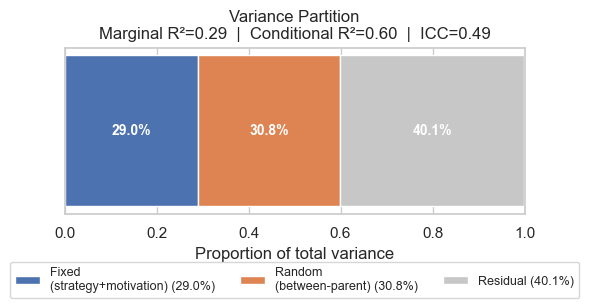

In [8]:
# Variance of the fixed-effect linear predictor from M2
# = total fitted - random intercept contribution
rand_contrib = pd.Series(
    [float(r2.random_effects[pid].iloc[0]) for pid in df_both['parent_id']],
    index=df_both.index
)
fixed_fitted = r2.fittedvalues - rand_contrib
var_fixed    = float(fixed_fitted.var())
var_random   = var_u2
var_resid    = var_e2
var_total    = var_fixed + var_random + var_resid

r2_marginal    = var_fixed / var_total
r2_conditional = (var_fixed + var_random) / var_total

partition = pd.DataFrame([{
    'component': 'Fixed effects (strategy + motivation)',
    'variance': round(var_fixed, 4),
    'proportion': round(var_fixed / var_total, 4),
}, {
    'component': 'Random intercept (between-parent)',
    'variance': round(var_random, 4),
    'proportion': round(var_random / var_total, 4),
}, {
    'component': 'Residual (within-parent)',
    'variance': round(var_resid, 4),
    'proportion': round(var_resid / var_total, 4),
}])

print('=== Variance Partition ===')
display(partition)
print(f'\nMarginal R²    (fixed only):          {r2_marginal:.3f}')
print(f'Conditional R² (fixed + random):      {r2_conditional:.3f}')
print(f'ICC (M0):                             {icc:.3f}')
print(f'Conditional ICC (M2):                 {cond_icc:.3f}')
print()
print('Interpretation:')
print(f'  Strategy + motivation explain {r2_marginal*100:.1f}% of total variance.')
print(f'  Adding parent intercepts explains another {(r2_conditional - r2_marginal)*100:.1f}%.')
print(f'  Remaining {(1-r2_conditional)*100:.1f}% is within-parent residual.')

partition.to_csv(OUTPUT_DIR / 'mixed_effects_variance_partition.csv', index=False)

# Stacked bar chart
colors = ['#4C72B0', '#DD8452', '#C7C7C7']
labels = ['Fixed\n(strategy+motivation)', 'Random\n(between-parent)', 'Residual']
props  = partition['proportion'].values

fig, ax = plt.subplots(figsize=(6, 3.5))
left = 0
for prop, color, label in zip(props, colors, labels):
    ax.barh(0, prop, left=left, color=color, edgecolor='white', height=0.5,
            label=f'{label} ({prop*100:.1f}%)')
    if prop > 0.04:
        ax.text(left + prop/2, 0, f'{prop*100:.1f}%', ha='center', va='center',
                fontsize=10, color='white', fontweight='bold')
    left += prop
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Proportion of total variance')
ax.set_title(
    f'Variance Partition\n'
    f'Marginal R²={r2_marginal:.2f}  |  Conditional R²={r2_conditional:.2f}  |  ICC={icc:.2f}'
)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mixed_effects_variance_partition.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Parent BLUPs (Random Intercepts)

=== Per-Parent BLUPs ===
Sum of BLUPs (should be ~0): 0.0000
SD of BLUPs: 0.8921


,blup,blup_se,n_rows
623519c893eaebfcb0046e26,-1.700,0.484,4
663dff19b292e4e2c5c11a1b,-1.257,0.444,5
62b5e825a5e8616bde25741d,-1.046,0.318,11
671e55aeca0216c5762de35a,-0.971,0.538,3
69c6965bfee6e955699f09e4,-0.912,0.413,6
671bbaf1bec15d847b871b9b,-0.689,0.387,7
69be087681bb16d5cd77fb03,-0.444,0.203,29
69c3239a158bfee31783d53f,-0.421,0.444,5
67095387c465675aea460ef4,-0.415,0.306,12
67c4c8f9fa9ba2b8a265b2f4,0.135,0.538,3


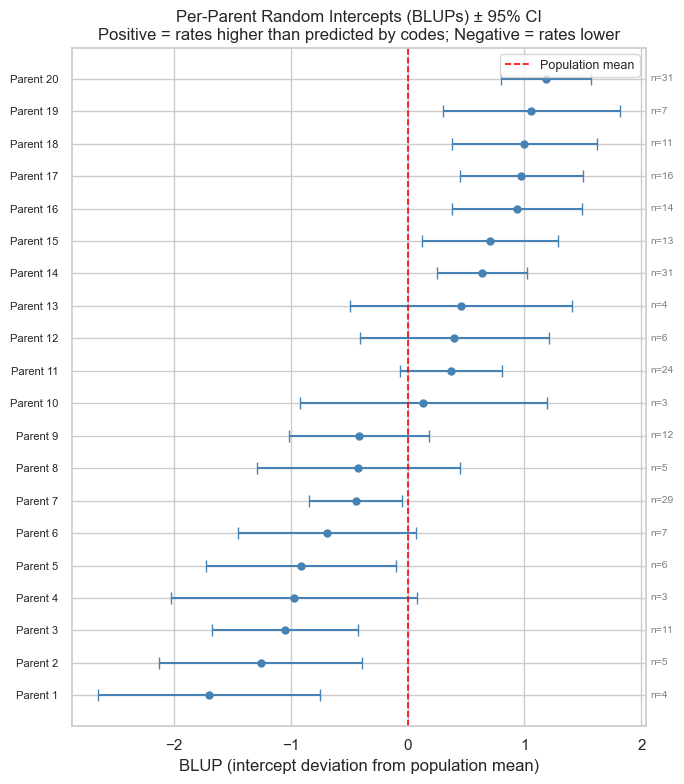

Saved: mixed_effects_blups.csv, mixed_effects_caterpillar.png


In [9]:
# BLUPs: per-parent intercept deviations from population mean
blups = pd.Series(
    {pid: float(v.iloc[0]) for pid, v in r2.random_effects.items()},
    name='blup'
).sort_values()

# Posterior SEs from random_effects_cov
blup_se = pd.Series(
    {pid: float(np.sqrt(max(float(v.iloc[0, 0]), 0)))
     for pid, v in r2.random_effects_cov.items()},
    name='blup_se'
)

blup_df = pd.concat([blups, blup_se], axis=1).sort_values('blup')
blup_df['n_rows'] = df_both.groupby('parent_id').size()

print('=== Per-Parent BLUPs ===')
print(f'Sum of BLUPs (should be ~0): {blups.sum():.4f}')
print(f'SD of BLUPs: {blups.std():.4f}')
display(blup_df.round(3))

# Caterpillar plot
n_parents = len(blup_df)
fig, ax = plt.subplots(figsize=(7, max(5, n_parents * 0.4)))
y_pos = range(n_parents)
ax.errorbar(
    blup_df['blup'], y_pos,
    xerr=1.96 * blup_df['blup_se'],
    fmt='o', color='steelblue', capsize=4, markersize=5
)
ax.axvline(0, color='red', linestyle='--', lw=1.2, label='Population mean')
for i, (pid, row) in enumerate(blup_df.iterrows()):
    ax.text(ax.get_xlim()[1] * 1.02 if ax.get_xlim()[1] > 0 else 0.05,
            i, f'n={int(row["n_rows"])}', va='center', fontsize=7.5, color='gray')
ax.set_yticks(y_pos)
ax.set_yticklabels([f'Parent {i+1}' for i in range(n_parents)], fontsize=8)
ax.set_xlabel('BLUP (intercept deviation from population mean)')
ax.set_title(
    'Per-Parent Random Intercepts (BLUPs) ± 95% CI\n'
    'Positive = rates higher than predicted by codes; Negative = rates lower'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mixed_effects_caterpillar.png', dpi=150, bbox_inches='tight')
plt.show()

blup_df.to_csv(OUTPUT_DIR / 'mixed_effects_blups.csv')
print('Saved: mixed_effects_blups.csv, mixed_effects_caterpillar.png')

## LOPO Link: Do High-BLUP Parents Benefit More from Per-Parent Classifiers?

LOPO columns: ['prolific_pid', 'n_test', 'model', 'F1', 'AUC', 'accuracy']


,prolific_pid,n_test,model,F1,AUC,accuracy
0,664502f636c5bc96a3e056cd,16,Majority Baseline,0.968,0.500,0.938
1,664502f636c5bc96a3e056cd,16,Logistic Regression,0.968,0.533,0.938
2,664502f636c5bc96a3e056cd,16,Random Forest,0.846,1.000,0.750
3,664502f636c5bc96a3e056cd,16,SVM (linear),0.968,0.500,0.938
4,610713aeac4904cc5d90e76d,14,Majority Baseline,1.000,NaN,1.000



Merged: 80 rows

BLUP magnitude vs AUC:
  Pearson r  = nan  p = nan
  Spearman r = nan  p = nan


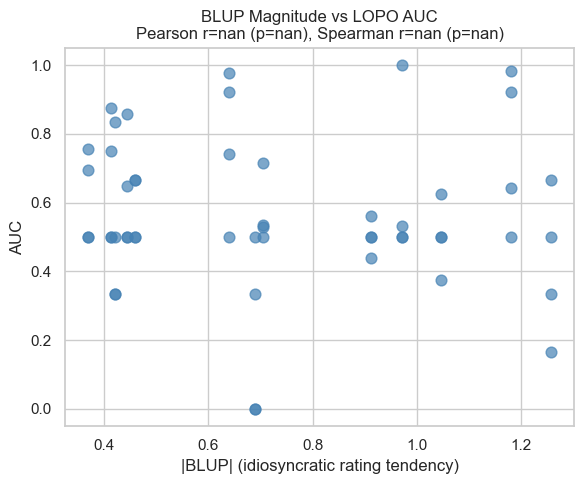

In [10]:
lopo_path = OUTPUT_DIR / 'classifier_output' / 'per_parent_lopo_universal.csv'

if not lopo_path.exists():
    print(f'LOPO file not found: {lopo_path}')
    print('Skipping BLUP-LOPO correlation. Run 1_classifier_per_parent.ipynb first.')
else:
    lopo = pd.read_csv(lopo_path)
    print('LOPO columns:', lopo.columns.tolist())
    display(lopo.head())

    # |BLUP| = magnitude of parent's idiosyncratic rating tendency
    blup_mag = blups.abs().rename('blup_magnitude')

    # Join on parent_id / pid — adjust column name if different
    pid_col = 'prolific_pid' if 'prolific_pid' in lopo.columns else lopo.columns[0]
    merged = lopo.merge(
        blup_mag.reset_index().rename(columns={'index': pid_col}),
        on=pid_col, how='inner'
    )
    print(f'\nMerged: {len(merged)} rows')

    # Find AUC column
    auc_cols = [c for c in merged.columns if 'auc' in c.lower() or 'AUC' in c]
    if not auc_cols:
        print('No AUC column found — print columns and inspect manually.')
        print(merged.columns.tolist())
    else:
        auc_col = auc_cols[0]
        r_p, p_p = pearsonr(merged['blup_magnitude'], merged[auc_col])
        r_s, p_s = spearmanr(merged['blup_magnitude'], merged[auc_col])

        print(f'\nBLUP magnitude vs {auc_col}:')
        print(f'  Pearson r  = {r_p:.3f}  p = {p_p:.4f}')
        print(f'  Spearman r = {r_s:.3f}  p = {p_s:.4f}')

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(merged['blup_magnitude'], merged[auc_col],
                   color='steelblue', alpha=0.7, s=60)
        ax.set_xlabel('|BLUP| (idiosyncratic rating tendency)')
        ax.set_ylabel(auc_col)
        ax.set_title(
            f'BLUP Magnitude vs LOPO AUC\n'
            f'Pearson r={r_p:.2f} (p={p_p:.3f}), Spearman r={r_s:.2f} (p={p_s:.3f})'
        )
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'mixed_effects_blup_vs_lopo.png', dpi=150, bbox_inches='tight')
        plt.show()

## Part 2 — Strategy-only and Motivation-only Models

Strategy is observable **a priori** — it is a property of the AI response, knowable before
any parent sees it, and its effects can in principle generalize to new highlights.

Motivation is **outcome-derived** — it reflects what a specific parent chose to attend to.
You cannot recover motivation from the AI response alone without first observing the highlight.

All three models (strategy-only, motivation-only, strategy+motivation) are re-fit on the
same `df_both` rows (n=242) so that variance proportions share a common denominator and are
directly comparable.

In [11]:
# ── Cell B: M_strategy_only ───────────────────────────────────────────────────
formula_strat = f'highlight_sentiment ~ C(model_strategy, Treatment("{REF_STRATEGY}"))'

r_strat = mixedlm(formula_strat, data=df_both, groups=df_both['parent_id']).fit(reml=True)

rand_strat       = pd.Series(
    [float(r_strat.random_effects[pid].iloc[0]) for pid in df_both['parent_id']],
    index=df_both.index
)
fixed_strat      = r_strat.fittedvalues - rand_strat
var_fixed_strat  = float(fixed_strat.var())
var_random_strat = float(r_strat.cov_re.iloc[0, 0])
var_resid_strat  = r_strat.scale

r2_marg_strat = var_fixed_strat / var_total
r2_cond_strat = (var_fixed_strat + var_random_strat) / var_total

print('=== M_strategy_only: Random intercepts, strategy fixed effect ===')
print(f'var_fixed  = {var_fixed_strat:.4f}  ({r2_marg_strat*100:.1f}% of shared var_total)')
print(f'var_random = {var_random_strat:.4f}  ({var_random_strat/var_total*100:.1f}%)')
print(f'var_resid  = {var_resid_strat:.4f}  ({var_resid_strat/var_total*100:.1f}%)')
print(f'Marginal R²    = {r2_marg_strat:.3f}')
print(f'Conditional R² = {r2_cond_strat:.3f}')
print()

fe_strat = pd.DataFrame({
    'coef': r_strat.params,
    'se':   r_strat.bse,
    'z':    r_strat.tvalues,
    'p':    r_strat.pvalues,
})
fe_strat.index = [clean_label(i) for i in fe_strat.index]
print('Fixed effects (strategy only):')
display(fe_strat.round(3))

=== M_strategy_only: Random intercepts, strategy fixed effect ===
var_fixed  = 0.1865  (6.0% of shared var_total)
var_random = 1.9545  (63.1%)
var_resid  = 1.6895  (54.5%)
Marginal R²    = 0.060
Conditional R² = 0.691

Fixed effects (strategy only):


,coef,se,z,p
Intercept,4.916,0.351,14.016,0.000
Clarify Child's Intent,0.425,0.383,1.109,0.267
Consider Age Group,-0.280,0.372,-0.753,0.451
Defer to Resources,0.145,0.952,0.152,0.879
Emphasize Emotional Support,0.336,0.283,1.185,0.236
Emphasize Risk Awareness,0.488,0.379,1.289,0.197
Encourage Introspection,-0.867,0.646,-1.343,0.179
Explain Problems in Prompt,0.150,0.481,0.312,0.755
Redirect with Alternatives,1.116,0.396,2.817,0.005
Refuse Response and Explain,1.349,0.664,2.032,0.042


In [12]:
# ── Cell C: M_motivation_only ─────────────────────────────────────────────────
formula_motiv = f'highlight_sentiment ~ C(motivation_pooled, Treatment("{REF_MOTIVATION}"))'

r_motiv = mixedlm(formula_motiv, data=df_both, groups=df_both['parent_id']).fit(reml=True)

rand_motiv       = pd.Series(
    [float(r_motiv.random_effects[pid].iloc[0]) for pid in df_both['parent_id']],
    index=df_both.index
)
fixed_motiv      = r_motiv.fittedvalues - rand_motiv
var_fixed_motiv  = float(fixed_motiv.var())
var_random_motiv = float(r_motiv.cov_re.iloc[0, 0])
var_resid_motiv  = r_motiv.scale

r2_marg_motiv = var_fixed_motiv / var_total
r2_cond_motiv = (var_fixed_motiv + var_random_motiv) / var_total

print('=== M_motivation_only: Random intercepts, motivation fixed effect ===')
print(f'var_fixed  = {var_fixed_motiv:.4f}  ({r2_marg_motiv*100:.1f}% of shared var_total)')
print(f'var_random = {var_random_motiv:.4f}  ({var_random_motiv/var_total*100:.1f}%)')
print(f'var_resid  = {var_resid_motiv:.4f}  ({var_resid_motiv/var_total*100:.1f}%)')
print(f'Marginal R²    = {r2_marg_motiv:.3f}')
print(f'Conditional R² = {r2_cond_motiv:.3f}')
print()

fe_motiv = pd.DataFrame({
    'coef': r_motiv.params,
    'se':   r_motiv.bse,
    'z':    r_motiv.tvalues,
    'p':    r_motiv.pvalues,
})
fe_motiv.index = [clean_label(i) for i in fe_motiv.index]
print('Fixed effects (motivation only):')
display(fe_motiv.round(3))

=== M_motivation_only: Random intercepts, motivation fixed effect ===
var_fixed  = 0.6226  (20.1% of shared var_total)
var_random = 1.3470  (43.5%)
var_resid  = 1.3261  (42.8%)
Marginal R²    = 0.201
Conditional R² = 0.636

Fixed effects (motivation only):


,coef,se,z,p
Intercept,5.396,0.298,18.078,0.000
Response Complexity,-0.704,0.381,-1.847,0.065
Response Confirmation / Contradiction,-1.816,0.516,-3.522,0.000
Response Could Evoke Strong Emotions,0.497,0.236,2.111,0.035
Response Identification of the Root Cause,0.337,0.344,0.979,0.328
Response Organization,0.617,0.372,1.659,0.097
Response Risk Awareness,-1.529,0.237,-6.462,0.000
Group Var,1.016,0.405,2.509,0.012


=== 3-Model Variance Comparison (shared denominator = var_total from M_both) ===


,model,var_fixed,var_random,var_resid,R2_marginal,R2_conditional
0,Strategy only,0.1865,1.9545,1.6895,0.0602,0.6910
1,Motivation only,0.6226,1.3470,1.3261,0.2010,0.6357
2,Strategy + Motivation,0.9002,0.9547,1.2435,0.2905,0.5987



Motivation gap  (R²_both − R²_strat_only):  0.230
  -> Adding motivation explains 23.0% more variance.
  -> OUTCOME-CONTINGENT signal — not recoverable a priori from the AI response.

Strategy gap    (R²_both − R²_motiv_only):  0.090
  -> Adding strategy explains 9.0% more variance.
  -> A PRIORI GENERALIZABLE signal — knowable from the AI response alone.

Interpretation: motivation_gap >> strategy_gap
  Motivation is the dominant predictor, but it is outcome-derived.
  Predicting sentiment from AI responses alone recovers only the strategy component.

Saved: mixed_effects_model_comparison.csv


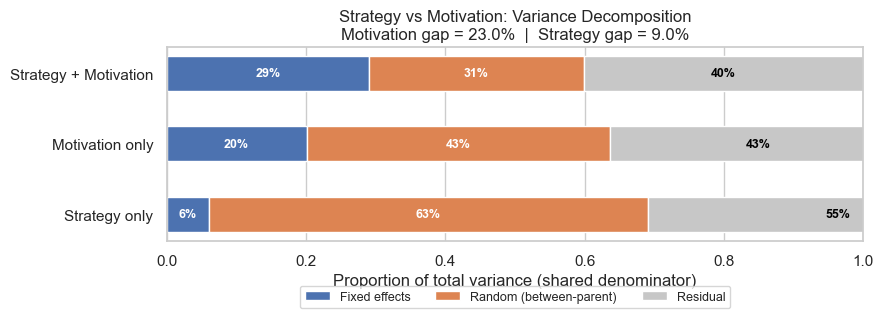

In [13]:
# ── Cell D: 3-model comparison table + stacked bar ───────────────────────────
motivation_gap = r2_marginal - r2_marg_strat   # outcome-contingent signal
strategy_gap   = r2_marginal - r2_marg_motiv   # a priori generalizable signal

comparison = pd.DataFrame([
    {
        'model':          'Strategy only',
        'var_fixed':      round(var_fixed_strat,  4),
        'var_random':     round(var_random_strat, 4),
        'var_resid':      round(var_resid_strat,  4),
        'R2_marginal':    round(r2_marg_strat,    4),
        'R2_conditional': round(r2_cond_strat,    4),
    },
    {
        'model':          'Motivation only',
        'var_fixed':      round(var_fixed_motiv,  4),
        'var_random':     round(var_random_motiv, 4),
        'var_resid':      round(var_resid_motiv,  4),
        'R2_marginal':    round(r2_marg_motiv,    4),
        'R2_conditional': round(r2_cond_motiv,    4),
    },
    {
        'model':          'Strategy + Motivation',
        'var_fixed':      round(var_fixed,        4),
        'var_random':     round(var_random,        4),
        'var_resid':      round(var_resid,         4),
        'R2_marginal':    round(r2_marginal,       4),
        'R2_conditional': round(r2_conditional,    4),
    },
])

print('=== 3-Model Variance Comparison (shared denominator = var_total from M_both) ===')
display(comparison)

print(f'\nMotivation gap  (R²_both − R²_strat_only):  {motivation_gap:.3f}')
print(f'  -> Adding motivation explains {motivation_gap*100:.1f}% more variance.')
print(f'  -> OUTCOME-CONTINGENT signal — not recoverable a priori from the AI response.')
print()
print(f'Strategy gap    (R²_both − R²_motiv_only):  {strategy_gap:.3f}')
print(f'  -> Adding strategy explains {strategy_gap*100:.1f}% more variance.')
print(f'  -> A PRIORI GENERALIZABLE signal — knowable from the AI response alone.')
print()

if motivation_gap > strategy_gap * 1.5:
    print('Interpretation: motivation_gap >> strategy_gap')
    print('  Motivation is the dominant predictor, but it is outcome-derived.')
    print('  Predicting sentiment from AI responses alone recovers only the strategy component.')
elif strategy_gap > motivation_gap * 1.5:
    print('Interpretation: strategy_gap >> motivation_gap')
    print('  The a priori signal (strategy) is the stronger component.')
    print('  Parent attention adds incremental but smaller signal on top.')
else:
    print('Interpretation: motivation and strategy gaps are roughly comparable.')
    print('  Both outcome-derived attention and a priori response properties contribute.')

comparison.to_csv(OUTPUT_DIR / 'mixed_effects_model_comparison.csv', index=False)
print('\nSaved: mixed_effects_model_comparison.csv')

# Stacked bar comparison
models = comparison['model'].tolist()
fp = comparison['var_fixed'].values  / var_total
rp = comparison['var_random'].values / var_total
ep = comparison['var_resid'].values  / var_total

fig, ax = plt.subplots(figsize=(9, 3.5))
y = list(range(len(models)))
ax.barh(y, fp,          color='#4C72B0', label='Fixed effects', height=0.5)
ax.barh(y, rp, left=fp, color='#DD8452', label='Random (between-parent)', height=0.5)
ax.barh(y, ep, left=fp+rp, color='#C7C7C7', label='Residual', height=0.5)

for i, (f, r, e) in enumerate(zip(fp, rp, ep)):
    if f > 0.03: ax.text(f/2,      i, f'{f*100:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if r > 0.03: ax.text(f+r/2,    i, f'{r*100:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if e > 0.03: ax.text(f+r+e/2,  i, f'{e*100:.0f}%', ha='center', va='center', fontsize=9, color='black', fontweight='bold')

ax.set_xlim(0, 1)
ax.set_yticks(y)
ax.set_yticklabels(models)
ax.set_xlabel('Proportion of total variance (shared denominator)')
ax.set_title(
    f'Strategy vs Motivation: Variance Decomposition\n'
    f'Motivation gap = {motivation_gap*100:.1f}%  |  Strategy gap = {strategy_gap*100:.1f}%'
)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mixed_effects_strategy_vs_motivation.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Cell E: AIC/BIC + LRT (ML fits) ──────────────────────────────────────────
r_strat_ml = mixedlm(formula_strat, data=df_both, groups=df_both['parent_id']).fit(reml=False)
r_motiv_ml = mixedlm(formula_motiv, data=df_both, groups=df_both['parent_id']).fit(reml=False)
r_both_ml  = mixedlm(formula_fe,    data=df_both, groups=df_both['parent_id']).fit(reml=False)

aic_bic = pd.DataFrame([
    {'model': 'Strategy only',       'n_params': len(r_strat_ml.params),
     'loglik': round(r_strat_ml.llf, 2), 'AIC': round(r_strat_ml.aic, 2), 'BIC': round(r_strat_ml.bic, 2)},
    {'model': 'Motivation only',     'n_params': len(r_motiv_ml.params),
     'loglik': round(r_motiv_ml.llf, 2), 'AIC': round(r_motiv_ml.aic, 2), 'BIC': round(r_motiv_ml.bic, 2)},
    {'model': 'Strategy+Motivation', 'n_params': len(r_both_ml.params),
     'loglik': round(r_both_ml.llf,  2), 'AIC': round(r_both_ml.aic,  2), 'BIC': round(r_both_ml.bic,  2)},
])

print('=== AIC/BIC (ML fits) ===')
display(aic_bic)

# LRT: Strategy-only vs Strategy+Motivation (does motivation add beyond strategy?)
D_motiv     = -2.0 * (r_strat_ml.llf - r_both_ml.llf)
df_motiv_lrt = len(r_both_ml.params) - len(r_strat_ml.params)
p_motiv_lrt  = chi2.sf(D_motiv, df=df_motiv_lrt)

print(f'\nLRT: Strategy-only vs Strategy+Motivation')
print(f'  D = {D_motiv:.3f}  df = {df_motiv_lrt}  p = {p_motiv_lrt:.4f}')
if p_motiv_lrt < 0.05:
    print('  -> Motivation significantly improves fit beyond strategy alone.')
else:
    print('  -> Motivation does NOT significantly improve fit beyond strategy alone.')

# LRT: Motivation-only vs Strategy+Motivation (does strategy add beyond motivation?)
D_strat      = -2.0 * (r_motiv_ml.llf - r_both_ml.llf)
df_strat_lrt = len(r_both_ml.params) - len(r_motiv_ml.params)
p_strat_lrt  = chi2.sf(D_strat, df=df_strat_lrt)

print(f'\nLRT: Motivation-only vs Strategy+Motivation')
print(f'  D = {D_strat:.3f}  df = {df_strat_lrt}  p = {p_strat_lrt:.4f}')
if p_strat_lrt < 0.05:
    print('  -> Strategy significantly improves fit beyond motivation alone.')
else:
    print('  -> Strategy does NOT significantly improve fit beyond motivation alone.')

aic_bic.to_csv(OUTPUT_DIR / 'mixed_effects_aic_bic.csv', index=False)
print('\nSaved: mixed_effects_aic_bic.csv')

=== AIC/BIC (ML fits) ===


,model,n_params,loglik,AIC,BIC
0,Strategy only,12,-425.95,877.91,923.26
1,Motivation only,8,-397.56,813.12,844.52
2,Strategy+Motivation,18,-382.09,802.18,868.47



LRT: Strategy-only vs Strategy+Motivation
  D = 87.730  df = 6  p = 0.0000
  -> Motivation significantly improves fit beyond strategy alone.

LRT: Motivation-only vs Strategy+Motivation
  D = 30.944  df = 10  p = 0.0006
  -> Strategy significantly improves fit beyond motivation alone.

Saved: mixed_effects_aic_bic.csv
